In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter openpyxl


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
print("All good! Ready to build. 🚀")


All good! Ready to build. 🚀


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print("Libraries loaded ✅")

Libraries loaded ✅


In [8]:
# Load all 5 dataset
orders = pd.read_csv(r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data\olist_orders_dataset1.csv")
customers = pd.read_csv(r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data\olist_customers_dataset.csv")
items = pd.read_csv(r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data\olist_order_items_dataset.csv")
payments = pd.read_csv(r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data\olist_order_payments_dataset.csv")
reviews = pd.read_csv(r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data\olist_order_reviews_dataset.csv")

print("orders shape:", orders.shape)
print("customers shape:", customers.shape)
print("items shape:", items.shape)
print("payments shape:", payments.shape)
print("reviews shape:", reviews.shape)

orders shape: (99441, 8)
customers shape: (99441, 5)
items shape: (112650, 7)
payments shape: (103886, 5)
reviews shape: (99224, 7)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data"

orders    = pd.read_csv(base + r"\olist_orders_dataset1.csv")       # ← has '1'
customers = pd.read_csv(base + r"\olist_customers_dataset.csv")
items     = pd.read_csv(base + r"\olist_order_items_dataset.csv")
payments  = pd.read_csv(base + r"\olist_order_payments_dataset.csv")
reviews   = pd.read_csv(base + r"\olist_order_reviews_dataset.csv")

print("orders shape:   ", orders.shape)
print("customers shape:", customers.shape)
print("items shape:    ", items.shape)
print("payments shape: ", payments.shape)
print("reviews shape:  ", reviews.shape)
print("\nData loaded ✅")

orders shape:    (99441, 8)
customers shape: (99441, 5)
items shape:     (112650, 7)
payments shape:  (103886, 5)
reviews shape:   (99224, 7)

Data loaded ✅


In [13]:
import os

# This will list EVERYTHING inside your Data folder
data_path = r"C:\Users\rushikesh\Downloads\ecommerce-churn\Data"

for root, dirs, files in os.walk(data_path):
    print("📁 Folder:", root)
    for f in files:
        print("   📄", f)
    for d in dirs:
        print("   📁", d)

📁 Folder: C:\Users\rushikesh\Downloads\ecommerce-churn\Data
   📄 olist_customers_dataset.csv
   📄 olist_orders_dataset1.csv
   📄 olist_order_items_dataset.csv
   📄 olist_order_payments_dataset.csv
   📄 olist_order_reviews_dataset.csv


In [15]:
for name, df in [("orders", orders), ("customers", customers), 
                  ("items", items), ("payments", payments), ("reviews", reviews)]:
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values across {df.shape[1]} columns")

orders: 4908 missing values across 8 columns
customers: 0 missing values across 5 columns
items: 0 missing values across 7 columns
payments: 0 missing values across 5 columns
reviews: 145903 missing values across 7 columns


In [16]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [17]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Date columns converted ✅")

Date columns converted ✅


In [18]:
print("Earliest order:", orders['order_purchase_timestamp'].min())
print("Latest order:  ", orders['order_purchase_timestamp'].max())
print("Total months of data:", 
      round((orders['order_purchase_timestamp'].max() - 
             orders['order_purchase_timestamp'].min()).days / 30))

Earliest order: 2016-09-04 21:15:19
Latest order:   2018-10-17 17:30:18
Total months of data: 26


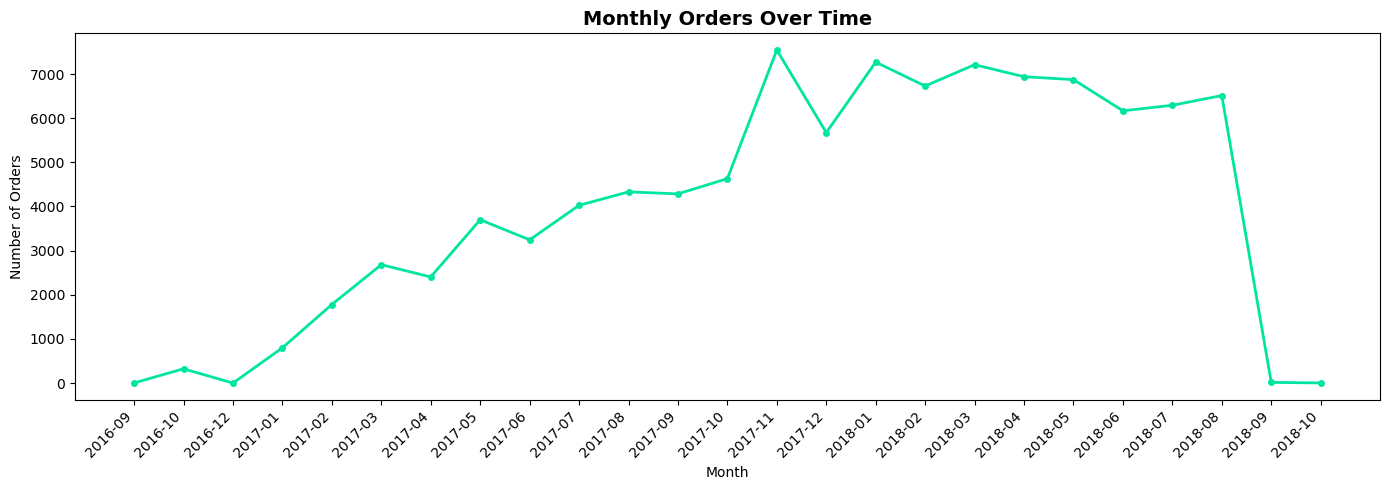

Chart saved ✅


In [20]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size().reset_index(name='order_count')

plt.figure(figsize=(14, 5))
plt.plot(monthly['month'].astype(str), monthly['order_count'],
         color='#00e5a0', linewidth=2, marker='o', markersize=4)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Orders Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.tight_layout()

# Save directly to your Data folder — no permission issues
plt.savefig(base + r"\monthly_orders.png", dpi=150)
plt.show()
print("Chart saved ✅")